Let's create Bell State. That is Entagled!!

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

# Create Circuit

bell = QuantumCircuit(2, 2)

# Apply H Gate

bell.h(0)

# Apply C Not (Control 0, target 1)

bell.cx(0, 1)

# Measure
bell.measure((0,1), (0, 1))


bell.draw('mpl')

# Compile Run 
job = simulator.run(transpile(bell, simulator), shots= 1024)
counts = job.result().get_counts()

print(f"Result is: {counts}")

Result is: {'11': 528, '00': 496}


In [33]:
# Extract outcome for each output

count_00 = counts.get('00', 0)
count_01 = counts.get('01', 0)
count_10 = counts.get('10', 0)
count_11 = counts.get('11', 0)


# Print the percentage of each output

print(f"count of 00 is: {count_00} times and {count_00/1024*100:5.1f}%")
print(f"count of 01 is: {count_01} times and {count_01/1024*100:5.1f}%")
print(f"count of 10 is:{count_10} times and {count_10/1024*100:5.1f}%")
print(f"count of 11 is:{count_11} times and {count_11/1024*100:5.1f}%")

count of 00 is: 496 times and  48.4%
count of 01 is: 0 times and   0.0%
count of 10 is:0 times and   0.0%
count of 11 is:528 times and  51.6%


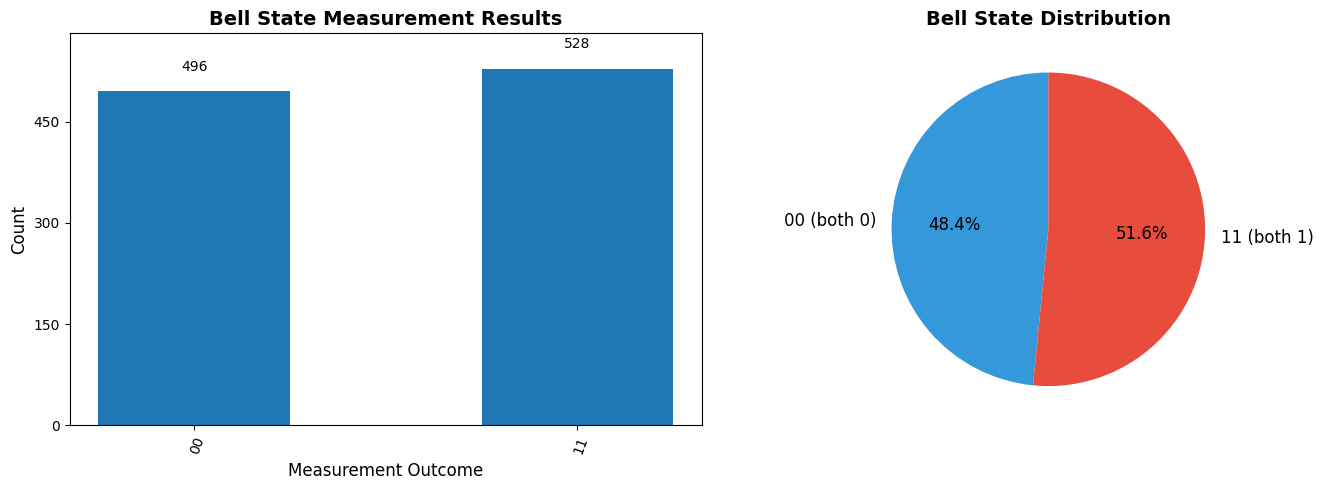

Notice: Only TWO outcomes appear!
'00' and '11' - never '01' or '10'!
This is the signature of entanglement! 🎯


In [36]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create a beautiful visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
plot_histogram(counts, ax=ax1)
ax1.set_title('Bell State Measurement Results', fontsize=14, fontweight='bold')
ax1.set_xlabel('Measurement Outcome', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

# Pie chart
outcomes_present = [count_00, count_11]
labels_present = ['00 (both 0)', '11 (both 1)']
colors = ['#3498db', '#e74c3c']

ax2.pie(outcomes_present, labels=labels_present, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12})
ax2.set_title('Bell State Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Notice: Only TWO outcomes appear!")
print("'00' and '11' - never '01' or '10'!")
print("This is the signature of entanglement! 🎯")

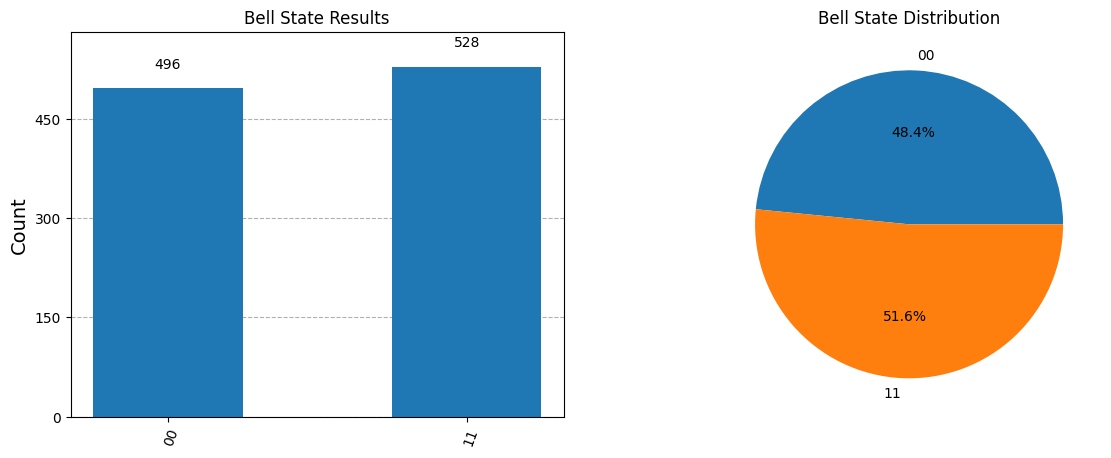

In [44]:


plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
plot_histogram(counts, ax=plt.gca())
plt.title("Bell State Results")
# plt.subplot(1, 2, 1)
# plot_histogram(counts)
# plt.title("Bell State Results")

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(
    [count_00, count_11],
    labels=['00', '11'],
    autopct='%1.1f%%'
)
plt.title("Bell State Distribution")

plt.show()


In [5]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
# The complete family of Bell states

print("═══════════════════════════════════")
print("THE FOUR BELL STATES")
print("═══════════════════════════════════")
print()

bell_states = []

# Φ⁺ (Phi-plus): The one we made
bell_phi_plus = QuantumCircuit(2, 2)
bell_phi_plus.h(0)
bell_phi_plus.cx(0, 1)
bell_phi_plus.measure([0, 1], [0, 1])
bell_states.append(("Φ⁺", bell_phi_plus, "(|00⟩ + |11⟩)/√2"))

# Φ⁻ (Phi-minus): Add Z gate
bell_phi_minus = QuantumCircuit(2, 2)
bell_phi_minus.h(0)
bell_phi_minus.cx(0, 1)
bell_phi_minus.z(0)
bell_phi_minus.measure([0, 1], [0, 1])
bell_states.append(("Φ⁻", bell_phi_minus, "(|00⟩ - |11⟩)/√2"))

# Ψ⁺ (Psi-plus): Add X gate
bell_psi_plus = QuantumCircuit(2, 2)
bell_psi_plus.h(0)
bell_psi_plus.cx(0, 1)
bell_psi_plus.x(1)
bell_psi_plus.measure([0, 1], [0, 1])
bell_states.append(("Ψ⁺", bell_psi_plus, "(|01⟩ + |10⟩)/√2"))

# Ψ⁻ (Psi-minus): Add X and Z
bell_psi_minus = QuantumCircuit(2, 2)
bell_psi_minus.h(0)
bell_psi_minus.cx(0, 1)
bell_psi_minus.x(1)
bell_psi_minus.z(0)
bell_psi_minus.measure([0, 1], [0, 1])
bell_states.append(("Ψ⁻", bell_psi_minus, "(|01⟩ - |10⟩)/√2"))

# Run all four
print("Running all four Bell states...")
print()

for name, circuit, math_form in bell_states:
    job = simulator.run(transpile(circuit, simulator), shots=1024)
    counts = job.result().get_counts()
    print(f"{name}: {math_form}")
    print(f"     Results: {counts}")
    print()

print("Notice:")
print("  Φ⁺, Φ⁻: Give '00' and '11' (qubits match)")
print("  Ψ⁺, Ψ⁻: Give '01' and '10' (qubits opposite)")
print("  All four are MAXIMALLY ENTANGLED!")

═══════════════════════════════════
THE FOUR BELL STATES
═══════════════════════════════════

Running all four Bell states...

Φ⁺: (|00⟩ + |11⟩)/√2
     Results: {'11': 498, '00': 526}

Φ⁻: (|00⟩ - |11⟩)/√2
     Results: {'00': 495, '11': 529}

Ψ⁺: (|01⟩ + |10⟩)/√2
     Results: {'01': 497, '10': 527}

Ψ⁻: (|01⟩ - |10⟩)/√2
     Results: {'01': 492, '10': 532}

Notice:
  Φ⁺, Φ⁻: Give '00' and '11' (qubits match)
  Ψ⁺, Ψ⁻: Give '01' and '10' (qubits opposite)
  All four are MAXIMALLY ENTANGLED!


Now I am going to write code for all four bell state and run on my own!!!

Φ⁺:(|00> +|11>)/√2
   Results: {'11': 541, '00': 483}

Φ⁻:(|00> -|11>)/√2
   Results: {'00': 503, '11': 521}

Ψ⁺:(|01> +|10>)/√2
   Results: {'01': 502, '10': 522}

Ψ⁻:(|01> -|10>)/√2
   Results: {'10': 525, '01': 499}



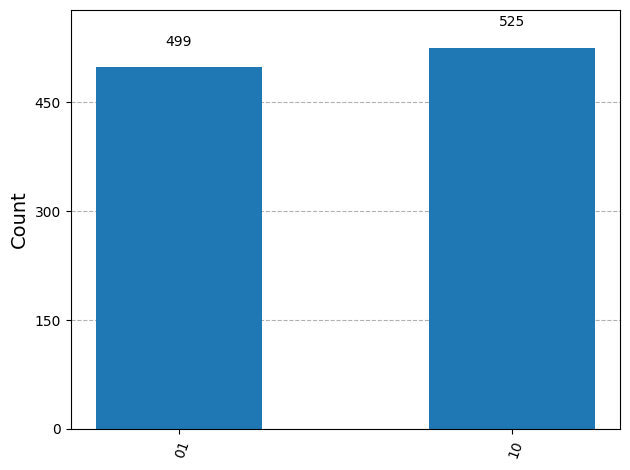

In [25]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

# Create empty list bell_state variable

bell_state = []


# Create phi + bell state, that we already made

bell_phi_plus = QuantumCircuit(2, 2)
bell_phi_plus.h(0)
bell_phi_plus.cx(0, 1)
bell_phi_plus.measure([0, 1],[0, 1])
bell_state.append(("Φ⁺", bell_phi_plus,"(|00> +|11>)/√2"))

# Create phi - bell state

bell_phi_minus = QuantumCircuit(2, 2)
bell_phi_minus.h(0)
bell_phi_minus.cx(0, 1)
bell_phi_minus.z(0)
bell_phi_minus.measure([0, 1],[0, 1])
bell_state.append(("Φ⁻", bell_phi_minus,"(|00> -|11>)/√2"))

#Create psi + bell 

bell_psi_plus = QuantumCircuit(2, 2)
bell_psi_plus.h(0)
bell_psi_plus.cx(0, 1)
bell_psi_plus.x(1)
bell_psi_plus.measure([0, 1],[0, 1])
bell_state.append(("Ψ⁺", bell_psi_plus,"(|01> +|10>)/√2"))

#Create psi - bell

bell_psi_minus = QuantumCircuit(2, 2)
bell_psi_minus.h(0)
bell_psi_minus.cx(0,1)
bell_psi_minus.x(1)
bell_psi_minus.z(1)
bell_psi_minus.measure([0, 1],[0, 1])
bell_state.append(("Ψ⁻", bell_psi_minus,"(|01> -|10>)/√2"))


for state, circuit , math in bell_state:
    job=simulator.run(transpile(circuit,simulator), shots=1024)
    counts= job.result().get_counts()
    print (f"{state}:{math}")
   
    print(f"   Results: {counts}")
    print()
    

plot_histogram(counts)



In [26]:
# Detailed statistical analysis of our Bell state

print("═══════════════════════════════════")
print("STATISTICAL VERIFICATION")
print("═══════════════════════════════════")
print()

# Get counts from our original Bell state run
c00 = counts.get('00', 0)
c01 = counts.get('01', 0)
c10 = counts.get('10', 0)
c11 = counts.get('11', 0)

print("Raw counts:")
print(f"  '00': {c00}")
print(f"  '01': {c01}")
print(f"  '10': {c10}")
print(f"  '11': {c11}")
print()

# Calculate fractions
total = c00 + c01 + c10 + c11
f00 = c00 / total
f01 = c01 / total
f10 = c10 / total
f11 = c11 / total

print("Fractions (actual):")
print(f"  P('00') = {f00:.4f}")
print(f"  P('01') = {f01:.4f}")
print(f"  P('10') = {f10:.4f}")
print(f"  P('11') = {f11:.4f}")
print()

print("Expected (theoretical):")
print("  P('00') = 0.5000")
print("  P('01') = 0.0000")
print("  P('10') = 0.0000")
print("  P('11') = 0.5000")
print()

# Calculate deviations
dev00 = abs(f00 - 0.5)
dev11 = abs(f11 - 0.5)

print("Deviations from expected:")
print(f"  '00': {dev00:.4f} ({dev00*100:.2f}%)")
print(f"  '11': {dev11:.4f} ({dev11*100:.2f}%)")
print()

if dev00 < 0.05 and dev11 < 0.05:
    print("✅ Results within expected statistical variation!")
    print("✅ Bell state successfully created!")
else:
    print("⚠️  Larger deviation than expected")
    print("   (Could be simulator noise or statistical fluctuation)")

═══════════════════════════════════
STATISTICAL VERIFICATION
═══════════════════════════════════

Raw counts:
  '00': 0
  '01': 499
  '10': 525
  '11': 0

Fractions (actual):
  P('00') = 0.0000
  P('01') = 0.4873
  P('10') = 0.5127
  P('11') = 0.0000

Expected (theoretical):
  P('00') = 0.5000
  P('01') = 0.0000
  P('10') = 0.0000
  P('11') = 0.5000

Deviations from expected:
  '00': 0.5000 (50.00%)
  '11': 0.5000 (50.00%)

⚠️  Larger deviation than expected
   (Could be simulator noise or statistical fluctuation)
